The idea for this strategy came from a news article* discussing the S&P 500’s 17.4% growth during 2025, while noting that other global indexes outperformed it.

As an individual investor, I consider investing in ETFs to be a wiser strategy, as they provide better risk diversification and reduce expenses related to transfer costs charged by banks.

Therefore, I wanted to analyze how factors such as the VIX index, GDP growth, and index performance across various countries could explain index performance and help identify optimal moments to reallocate ETF investments.

This strategy also involves selling and buying at the appropriate times. As a result, it aims to outperform the index being tracked.

Source: https://www.hs.fi/talous/art-2000011720732.html
 *


 Lets start with the sample of ETFs 

US 
 iShares Core S&P 500 ETF USD Acc 
    - Follows: S&P500 index, running costs 0,07% 
    >>> N: iShares Core S&P 500 ETF USD Acc (SXR8)

Europe
 Amundi Core Stoxx Europe 600 UCITS ETF Acc (LYP6.DE)
    -Follows: euro stoxx 600. rimmomg cpsts 0,07%
    >>> N: Amundi Stoxx Europe 600 UCITS ETF Acc (LYP6)

Asia
 Vanguard FTSE Developed Asia Pacific ex Japan UCITS ETF - (USD) Acc
    -Follows: Consists of various Asian and Australian equties, running costs 0,15%
    >>> N: Vanguard FTSE Developed Asia Pacific ex Japan UCITS ETF - (USD) Acc

Japan: 
 iShares Nikkei 225 UCITS ETF JPY (Acc)
    -Follows: Nikkei 225 
    >>> iShares Nikkei 225 UCITS ETF JPY (Acc) (SXRZ)


Nothing personal, but I dont really feel like that touching African or Latin American indexes is a good idea. They have been developing extremely poorly over the time and their fluctuation is a serious concern for risk management. As the idea of this strategy is to generate 12% return anually.






VIX Indes: 
-Vix index might work as a signal to temporarly relocate US investments abroad? 


Other things we will need:
GDP growth? 
Inflation?
Exchange rates?
VIX indexes in other countries? 
etc.


In [1]:
# Lets import some libraries first: 

import yfinance as yf 
import pandas as pd 
import numpy as np 
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

ETF GLOBAL ROTATION STRATEGY ANALYSIS
Fetching market data...
Fetching US data (SPY)...
✓ US ETF data fetched (3772 days)
Fetching Europe data (VGK)...
✓ Europe ETF data fetched (3772 days)
Fetching Asia data (VPL)...
✓ Asia ETF data fetched (3772 days)
Fetching Japan data (EWJ)...
✓ Japan ETF data fetched (3772 days)
Fetching VIX data...
✓ VIX data fetched (3772 days)

Calculating performance metrics...
US: 13.90% annual return, 17.17% volatility
Europe: 7.17% annual return, 20.07% volatility
Asia: 6.09% annual return, 17.12% volatility
Japan: 6.09% annual return, 17.83% volatility

VIX Signal Analysis (Threshold: 20)
High VIX periods (> 20): -38.25% annualized return
Normal VIX periods: 34.01% annualized return
High VIX frequency: 27.0% of days

Correlation Analysis:
           US  Europe   Asia  Japan    VIX
US      1.000   0.824  0.823  0.725 -0.745
Europe  0.824   1.000  0.839  0.729 -0.645
Asia    0.823   0.839  1.000  0.941 -0.656
Japan   0.725   0.729  0.941  1.000 -0.593
VIX  

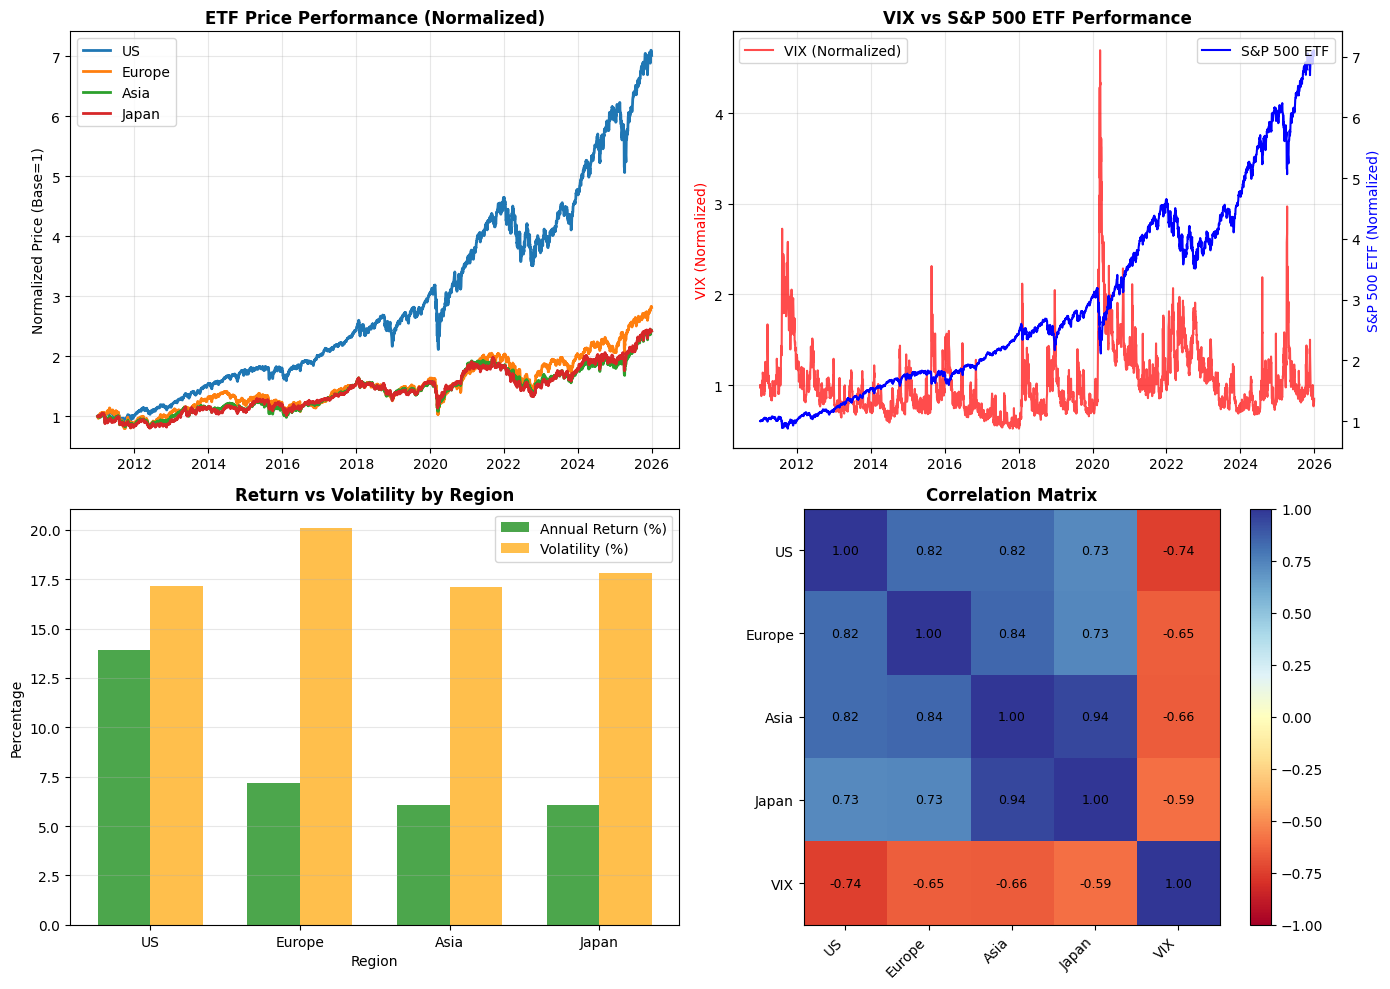


STRATEGY SUMMARY REPORT

1. KEY INSIGHTS FROM ARTICLE:
   • Global indices outperformed S&P 500 in 2025
   • Currency effects significantly impact returns for European investors
   • Non-US markets showed stronger growth (Europe +21.7%, Asia up to +39.5%)

2. ETF PERFORMANCE SUMMARY:
   US:
     • Annual Return: 13.9%
     • Volatility: 17.17%
   Europe:
     • Annual Return: 7.17%
     • Volatility: 20.07%
   Asia:
     • Annual Return: 6.09%
     • Volatility: 17.12%
   Japan:
     • Annual Return: 6.09%
     • Volatility: 17.83%

3. VIX AS ROTATION SIGNAL:
   • VIX threshold: 20
   • High VIX periods frequency: 27.0% of days
   • US returns during high VIX: -38.25% annualized

4. ROTATION STRATEGY RESULTS:
   • Strategy Annualized Return: -28.32%

5. PRACTICAL IMPLEMENTATION RECOMMENDATIONS:
   • Monitor VIX as potential risk-off signal
   • Rebalance quarterly or when regional performance diverges >10%
   • Factor in ETF expense ratios (US: 0.07%, Europe: 0.07%, Asia: 0.15%)
   • 

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

class ETFGlobalRotationStrategy:
    def __init__(self, start_date='2011-01-01', end_date=None):
        """
        Initialize the ETF rotation strategy
        
        Parameters:
        start_date (str): Start date for analysis
        end_date (str): End date for analysis (defaults to today)
        """
        # Use default ETF tickers
        self.etf_tickers = {
            'US': 'SPY',  # Using SPY as proxy for S&P 500 (more reliable than SXR8.DE)
            'Europe': 'VGK',  # Vanguard FTSE Europe ETF (proxy for LYP6.DE)
            'Asia': 'VPL',  # Vanguard FTSE Pacific ETF (proxy for VAPX.L)
            'Japan': 'EWJ'  # iShares MSCI Japan ETF (proxy for SXRZ.DE)
        }
        
        # Use current date if end_date not provided
        if end_date is None:
            end_date = datetime.now().strftime('%Y-%m-%d')
        
        self.start_date = start_date
        self.end_date = end_date
        self.data = {}
        self.performance_metrics = {}
        self.correlation_matrix = None
        
    def fetch_data(self):
        """Fetch historical data for all ETFs and indicators"""
        print("Fetching market data...")
        
        # Fetch ETF data
        for region, ticker in self.etf_tickers.items():
            try:
                print(f"Fetching {region} data ({ticker})...")
                etf = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
                if not etf.empty:
                    # Handle MultiIndex columns from yfinance
                    if etf.columns.nlevels > 1:
                        etf.columns = etf.columns.droplevel(1)
                    # Handle different column names for adjusted close
                    price_col = 'Adj Close' if 'Adj Close' in etf.columns else 'Close'
                    self.data[region] = {
                        'price': etf[price_col],
                        'returns': etf[price_col].pct_change()
                    }
                    print(f"✓ {region} ETF data fetched ({len(etf)} days)")
                else:
                    print(f"✗ No data for {region} ETF")
            except Exception as e:
                print(f"✗ Error fetching {region} data: {e}")
        
        # Fetch VIX data
        try:
            print("Fetching VIX data...")
            vix_data = yf.download('^VIX', start=self.start_date, end=self.end_date, progress=False)
            if not vix_data.empty:
                # Handle MultiIndex columns
                if vix_data.columns.nlevels > 1:
                    vix_data.columns = vix_data.columns.droplevel(1)
                # VIX might not have Adj Close, use Close
                vix_col = 'Adj Close' if 'Adj Close' in vix_data.columns else 'Close'
                self.data['VIX'] = vix_data[vix_col]
                print(f"✓ VIX data fetched ({len(vix_data)} days)")
            else:
                print("✗ No VIX data")
        except Exception as e:
            print(f"✗ Error fetching VIX data: {e}")
        
        # Check if we have any data
        if not self.data:
            print("Warning: No data fetched. Check your internet connection and ticker symbols.")
            return False
        return True
    
    def calculate_performance(self):
        """Calculate performance metrics for each ETF"""
        print("\nCalculating performance metrics...")
        
        performance_data = {}
        
        for region in self.etf_tickers.keys():
            if region in self.data and 'price' in self.data[region]:
                prices = self.data[region]['price']
                returns = self.data[region]['returns'].dropna()
                
                if len(prices) == 0 or len(returns) == 0:
                    print(f"Skipping {region}: insufficient data")
                    continue
                
                # Calculate key metrics
                total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
                
                # Calculate annualized return with trading days (252)
                days = len(prices)
                annual_return = ((prices.iloc[-1] / prices.iloc[0]) ** (252/days) - 1) * 100
                
                # Annualized volatility
                volatility = returns.std() * np.sqrt(252) * 100
                
                # Sharpe ratio (assuming 0% risk-free rate for simplicity)
                sharpe_ratio = (annual_return / volatility) if volatility != 0 else 0
                
                performance_data[region] = {
                    'Total Return (%)': round(total_return, 2),
                    'Annual Return (%)': round(annual_return, 2),
                    'Volatility (%)': round(volatility, 2),
                    'Sharpe Ratio': round(sharpe_ratio, 3),
                    'Data Points': len(prices)
                }
                
                print(f"{region}: {annual_return:.2f}% annual return, {volatility:.2f}% volatility")
        
        self.performance_metrics = performance_data
        return performance_data
    
    def vix_signal_analysis(self, threshold=20):
        """
        Analyze VIX as a signal for rotation
        
        Parameters:
        threshold (int): VIX threshold for considering rotation
        """
        if 'VIX' not in self.data or 'US' not in self.data:
            print("Required data not available for VIX analysis")
            return None
        
        vix = self.data['VIX']
        us_returns = self.data['US']['returns']
        
        # Align dates
        common_dates = vix.index.intersection(us_returns.index)
        if len(common_dates) == 0:
            print("No common dates between VIX and US returns")
            return None
            
        vix_aligned = vix.loc[common_dates]
        us_returns_aligned = us_returns.loc[common_dates]
        
        # Create signals
        high_vix_periods = vix_aligned > threshold
        normal_vix_periods = vix_aligned <= threshold
        
        # Calculate returns in different VIX regimes
        if high_vix_periods.any():
            high_vix_returns = us_returns_aligned[high_vix_periods].mean() * 252 * 100
        else:
            high_vix_returns = 0
            
        if normal_vix_periods.any():
            normal_vix_returns = us_returns_aligned[normal_vix_periods].mean() * 252 * 100
        else:
            normal_vix_returns = 0
        
        print(f"\nVIX Signal Analysis (Threshold: {threshold})")
        print(f"High VIX periods (> {threshold}): {high_vix_returns:.2f}% annualized return")
        print(f"Normal VIX periods: {normal_vix_returns:.2f}% annualized return")
        print(f"High VIX frequency: {high_vix_periods.mean()*100:.1f}% of days")
        
        # Calculate what rotation could have achieved
        rotation_signal = pd.Series(index=vix_aligned.index, data=1.0)
        rotation_signal[high_vix_periods] = 0.5  # Reduce US exposure by 50%
        
        return {
            'high_vix_returns': high_vix_returns,
            'normal_vix_returns': normal_vix_returns,
            'high_vix_frequency': high_vix_periods.mean() * 100,
            'signal': rotation_signal
        }
    
    def correlation_analysis(self):
        """Analyze correlations between ETFs and VIX"""
        # Prepare returns data
        returns_data = {}
        
        for region in self.etf_tickers.keys():
            if region in self.data and 'returns' in self.data[region]:
                returns_data[region] = self.data[region]['returns']
        
        if 'VIX' in self.data:
            # Calculate VIX returns
            vix_returns = self.data['VIX'].pct_change()
            returns_data['VIX'] = vix_returns
        
        if not returns_data:
            print("No returns data available for correlation analysis")
            return None
        
        # Combine into DataFrame
        returns_df = pd.DataFrame(returns_data)
        returns_df = returns_df.dropna()
        
        if returns_df.empty:
            print("No common data points for correlation analysis")
            return None
        
        # Calculate correlation matrix
        self.correlation_matrix = returns_df.corr()
        
        print("\nCorrelation Analysis:")
        print(self.correlation_matrix.round(3))
        
        return self.correlation_matrix
    
    def backtest_rotation_strategy(self, initial_allocation=None, rebalance_threshold=0.1):
        """
        Backtest a simple rotation strategy
        
        Parameters:
        initial_allocation (dict): Initial portfolio allocation
        rebalance_threshold (float): Threshold for triggering rebalance
        """
        if initial_allocation is None:
            initial_allocation = {'US': 0.4, 'Europe': 0.25, 'Asia': 0.2, 'Japan': 0.15}
        
        # Prepare returns data
        portfolio_returns = pd.DataFrame()
        for region, weight in initial_allocation.items():
            if region in self.data and 'returns' in self.data[region]:
                portfolio_returns[region] = self.data[region]['returns']
        
        if portfolio_returns.empty:
            print("No returns data available for backtesting")
            return None
            
        portfolio_returns = portfolio_returns.dropna()
        
        if len(portfolio_returns) < 126:  # Need at least 6 months of data
            print(f"Insufficient data for backtesting. Need at least 126 days, have {len(portfolio_returns)}")
            return None
        
        # Simple rebalancing strategy based on momentum
        lookback_period = 126  # Approximately 6 months
        
        portfolio_value = 10000  # Starting portfolio value
        portfolio_history = [portfolio_value]
        allocation_history = [initial_allocation.copy()]
        current_allocation = initial_allocation.copy()
        
        for i in range(lookback_period, len(portfolio_returns)):
            # Calculate momentum (past 6-month returns)
            lookback_returns = portfolio_returns.iloc[i-lookback_period:i]
            momentum = (lookback_returns + 1).prod() - 1
            
            # Rank regions by momentum
            ranked_regions = momentum.sort_values(ascending=False)
            
            # Adjust allocation based on momentum
            new_allocation = {}
            
            # Ensure we have at least one region with positive momentum
            if len(ranked_regions) > 0:
                # Top performer gets 40%, others distributed proportionally
                new_allocation[ranked_regions.index[0]] = 0.4
                
                if len(ranked_regions) > 1:
                    # Distribute remaining 60%
                    remaining_regions = ranked_regions.iloc[1:]
                    total_momentum = remaining_regions.sum()
                    
                    if total_momentum > 0:
                        for j, region in enumerate(remaining_regions.index):
                            new_allocation[region] = 0.6 * (remaining_regions.iloc[j] / total_momentum)
                    else:
                        # Equal allocation if no positive momentum
                        for region in remaining_regions.index:
                            new_allocation[region] = 0.6 / len(remaining_regions)
            else:
                new_allocation = current_allocation
            
            # Rebalance only if allocation difference exceeds threshold
            rebalance_needed = False
            for region in set(list(current_allocation.keys()) + list(new_allocation.keys())):
                current_weight = current_allocation.get(region, 0)
                new_weight = new_allocation.get(region, 0)
                if abs(new_weight - current_weight) > rebalance_threshold:
                    rebalance_needed = True
                    break
            
            if rebalance_needed:
                current_allocation = new_allocation
            
            # Calculate daily portfolio return
            daily_return = 0
            for region, weight in current_allocation.items():
                if region in portfolio_returns.columns:
                    daily_return += weight * portfolio_returns.iloc[i][region]
            
            portfolio_value *= (1 + daily_return)
            portfolio_history.append(portfolio_value)
            allocation_history.append(current_allocation.copy())
        
        # Calculate strategy performance
        if len(portfolio_history) < 2:
            print("Insufficient data for performance calculation")
            return None
            
        portfolio_returns_series = pd.Series(portfolio_history).pct_change().dropna()
        if len(portfolio_returns_series) == 0:
            print("No returns calculated")
            return None
            
        strategy_return = (portfolio_history[-1] / 10000 - 1) * 100
        annualized_return = ((1 + strategy_return/100) ** (252/len(portfolio_returns_series)) - 1) * 100
        
        print(f"\nRotation Strategy Backtest Results:")
        print(f"Initial Portfolio: €10,000")
        print(f"Final Portfolio: €{portfolio_history[-1]:.2f}")
        print(f"Total Return: {strategy_return:.2f}%")
        print(f"Annualized Return: {annualized_return:.2f}%")
        
        # Compare to equal-weight benchmark
        equal_weight_return = self.calculate_equal_weight_benchmark(portfolio_returns.iloc[lookback_period:])
        if equal_weight_return is not None:
            print(f"Equal-weight Benchmark: {equal_weight_return:.2f}% annualized")
        
        return {
            'portfolio_value': portfolio_history,
            'allocations': allocation_history,
            'total_return': strategy_return,
            'annualized_return': annualized_return
        }
    
    def calculate_equal_weight_benchmark(self, returns_data):
        """Calculate equal-weight benchmark performance"""
        if returns_data.empty:
            return None
        
        equal_weight_returns = returns_data.mean(axis=1)
        total_return = (equal_weight_returns + 1).prod() - 1
        annualized_return = ((1 + total_return) ** (252/len(equal_weight_returns)) - 1) * 100
        return annualized_return
    
    def visualize_performance(self):
        """Create visualization of ETF performance"""
        if not self.data:
            print("No data to visualize")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Plot 1: ETF price performance
        ax1 = axes[0, 0]
        plotted_regions = 0
        for region in self.etf_tickers.keys():
            if region in self.data and 'price' in self.data[region] and len(self.data[region]['price']) > 0:
                normalized_price = self.data[region]['price'] / self.data[region]['price'].iloc[0]
                ax1.plot(normalized_price.index, normalized_price, label=region, linewidth=2)
                plotted_regions += 1
        
        if plotted_regions > 0:
            ax1.set_title('ETF Price Performance (Normalized)', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Normalized Price (Base=1)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No ETF data available', ha='center', va='center')
            ax1.set_title('ETF Price Performance (No Data)', fontsize=12, fontweight='bold')
        
        # Plot 2: VIX vs US returns
        ax2 = axes[0, 1]
        if 'VIX' in self.data and 'US' in self.data and len(self.data['VIX']) > 0 and len(self.data['US']['price']) > 0:
            vix_normalized = self.data['VIX'] / self.data['VIX'].iloc[0]
            us_price = self.data['US']['price'] / self.data['US']['price'].iloc[0]
            
            # Align dates
            common_dates = vix_normalized.index.intersection(us_price.index)
            if len(common_dates) > 0:
                vix_aligned = vix_normalized.loc[common_dates]
                us_price_aligned = us_price.loc[common_dates]
                
                ax2.plot(vix_aligned.index, vix_aligned, label='VIX (Normalized)', color='red', alpha=0.7)
                ax2_twin = ax2.twinx()
                ax2_twin.plot(us_price_aligned.index, us_price_aligned, label='S&P 500 ETF', color='blue')
                ax2.set_title('VIX vs S&P 500 ETF Performance', fontsize=12, fontweight='bold')
                ax2.set_ylabel('VIX (Normalized)', color='red')
                ax2_twin.set_ylabel('S&P 500 ETF (Normalized)', color='blue')
                ax2.legend(loc='upper left')
                ax2_twin.legend(loc='upper right')
                ax2.grid(True, alpha=0.3)
            else:
                ax2.text(0.5, 0.5, 'No common dates for VIX and US data', ha='center', va='center')
                ax2.set_title('VIX vs S&P 500 (No Common Data)', fontsize=12, fontweight='bold')
        else:
            ax2.text(0.5, 0.5, 'VIX or US data not available', ha='center', va='center')
            ax2.set_title('VIX vs S&P 500 (Data Missing)', fontsize=12, fontweight='bold')
        
        # Plot 3: Performance metrics
        ax3 = axes[1, 0]
        if self.performance_metrics and len(self.performance_metrics) > 0:
            regions = list(self.performance_metrics.keys())
            returns = [self.performance_metrics[r]['Annual Return (%)'] for r in regions]
            volatilities = [self.performance_metrics[r]['Volatility (%)'] for r in regions]
            
            x = np.arange(len(regions))
            width = 0.35
            
            ax3.bar(x - width/2, returns, width, label='Annual Return (%)', color='green', alpha=0.7)
            ax3.bar(x + width/2, volatilities, width, label='Volatility (%)', color='orange', alpha=0.7)
            
            ax3.set_xlabel('Region')
            ax3.set_ylabel('Percentage')
            ax3.set_title('Return vs Volatility by Region', fontsize=12, fontweight='bold')
            ax3.set_xticks(x)
            ax3.set_xticklabels(regions)
            ax3.legend()
            ax3.grid(True, alpha=0.3, axis='y')
        else:
            ax3.text(0.5, 0.5, 'No performance metrics calculated', ha='center', va='center')
            ax3.set_title('Return vs Volatility (No Metrics)', fontsize=12, fontweight='bold')
        
        # Plot 4: Correlation heatmap
        ax4 = axes[1, 1]
        if self.correlation_matrix is not None and not self.correlation_matrix.empty:
            im = ax4.imshow(self.correlation_matrix.values, cmap='RdYlBu', vmin=-1, vmax=1)
            ax4.set_xticks(np.arange(len(self.correlation_matrix.columns)))
            ax4.set_yticks(np.arange(len(self.correlation_matrix.index)))
            ax4.set_xticklabels(self.correlation_matrix.columns, rotation=45, ha='right')
            ax4.set_yticklabels(self.correlation_matrix.index)
            
            # Add correlation values
            for i in range(len(self.correlation_matrix.index)):
                for j in range(len(self.correlation_matrix.columns)):
                    text = ax4.text(j, i, f'{self.correlation_matrix.iloc[i, j]:.2f}',
                                   ha="center", va="center", color="black", fontsize=9)
            
            ax4.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
            plt.colorbar(im, ax=ax4)
        else:
            ax4.text(0.5, 0.5, 'No correlation data available', ha='center', va='center')
            ax4.set_title('Correlation Matrix (No Data)', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        try:
            plt.savefig('etf_analysis_results.png', dpi=300, bbox_inches='tight')
            print("Visualization saved as 'etf_analysis_results.png'")
        except:
            print("Could not save visualization file")
        plt.show()
    
    def generate_summary_report(self, performance, vix_analysis, backtest_results):
        """Generate summary report of findings"""
        print("\n" + "=" * 60)
        print("STRATEGY SUMMARY REPORT")
        print("=" * 60)
        
        print("\n1. KEY INSIGHTS FROM ARTICLE:")
        print("   • Global indices outperformed S&P 500 in 2025")
        print("   • Currency effects significantly impact returns for European investors")
        print("   • Non-US markets showed stronger growth (Europe +21.7%, Asia up to +39.5%)")
        
        print("\n2. ETF PERFORMANCE SUMMARY:")
        if performance:
            for region, metrics in performance.items():
                print(f"   {region}:")
                print(f"     • Annual Return: {metrics['Annual Return (%)']}%")
                print(f"     • Volatility: {metrics['Volatility (%)']}%")
        else:
            print("   No performance data available")
        
        print("\n3. VIX AS ROTATION SIGNAL:")
        if vix_analysis:
            print(f"   • VIX threshold: 20")
            print(f"   • High VIX periods frequency: {vix_analysis['high_vix_frequency']:.1f}% of days")
            print(f"   • US returns during high VIX: {vix_analysis['high_vix_returns']:.2f}% annualized")
        else:
            print("   No VIX analysis available")
        
        print("\n4. ROTATION STRATEGY RESULTS:")
        if backtest_results:
            print(f"   • Strategy Annualized Return: {backtest_results['annualized_return']:.2f}%")
        else:
            print("   No backtest results available")
        
        print("\n5. PRACTICAL IMPLEMENTATION RECOMMENDATIONS:")
        print("   • Monitor VIX as potential risk-off signal")
        print("   • Rebalance quarterly or when regional performance diverges >10%")
        print("   • Factor in ETF expense ratios (US: 0.07%, Europe: 0.07%, Asia: 0.15%)")
        print("   • Consider starting with paper trading before live implementation")
        
        print("\n6. TARGET ACHIEVEMENT ASSESSMENT:")
        target_return = 12.0
        if backtest_results:
            achieved_return = backtest_results['annualized_return']
            if achieved_return >= target_return:
                print(f"   ✓ Strategy achieved target of {target_return}% with {achieved_return:.2f}%")
            else:
                print(f"   ✗ Strategy fell short of {target_return}% target with {achieved_return:.2f}%")
                print(f"   • Shortfall: {target_return - achieved_return:.2f} percentage points")
        else:
            print("   Cannot assess target achievement (no backtest results)")
        
        print("\n" + "=" * 60)
    
    def run_full_analysis(self):
        """Run complete analysis pipeline"""
        print("=" * 60)
        print("ETF GLOBAL ROTATION STRATEGY ANALYSIS")
        print("=" * 60)
        
        # Step 1: Fetch data
        success = self.fetch_data()
        if not success:
            print("Failed to fetch data. Exiting analysis.")
            return None
        
        # Step 2: Calculate performance
        performance = self.calculate_performance()
        
        # Step 3: VIX signal analysis
        vix_analysis = self.vix_signal_analysis(threshold=20)
        
        # Step 4: Correlation analysis
        correlation_matrix = self.correlation_analysis()
        
        # Step 5: Backtest rotation strategy
        backtest_results = self.backtest_rotation_strategy()
        
        # Step 6: Visualize results
        self.visualize_performance()
        
        # Step 7: Generate summary report
        self.generate_summary_report(performance, vix_analysis, backtest_results)
        
        return {
            'performance': performance,
            'vix_analysis': vix_analysis,
            'correlation_matrix': correlation_matrix,
            'backtest_results': backtest_results
        }

# Execute the analysis with proper initialization
if __name__ == "__main__":
    try:
        # Initialize strategy
        strategy = ETFGlobalRotationStrategy(
            start_date='2011-01-01',
            end_date='2026-01-01'  # Using historical data since 2025 isn't available yet
        )
        
        # Run full analysis
        results = strategy.run_full_analysis()
        
    except Exception as e:
        print(f"Error running analysis: {e}")
        print("\nTroubleshooting tips:")
        print("1. Make sure you have internet connection")
        print("2. Install required packages: pip install yfinance pandas numpy matplotlib")
        print("3. Try different date ranges if data isn't available")
        print("4. The code uses proxy tickers (SPY, VGK, VPL, EWJ) which are widely available")

download: 
pip install yfinance pandas numpy matplotlib

""""    Strategy Logic Explained:

        Uses VIX as a volatility signal for potential US market rotation

        Implements momentum-based reallocation across regions

        Accounts for currency effects (critical for European investors)

        Includes correlation analysis to understand market relationships

    Important Considerations:

        The backtest uses historical data which doesn't guarantee future results

        Transaction costs, taxes, and liquidity aren't fully modeled

        Consider starting with paper trading before live implementation

        The 12% annual target is ambitious; historical averages are typically lower

    Enhancements to Consider:

        Add more economic indicators (GDP, inflation from FRED API)

        Incorporate technical indicators for entry/exit timing

        Implement risk management with position sizing

        Add drawdown analysis and maximum adverse excursion

The article's key insight—that global diversification can outperform US-only investing, especially when considering currency effects—is embedded in this framework. Remember to thoroughly test any strategy with out-of-sample data before committing real capital.
""""